# Weather Condition Classification using Support Vector Machine (SVM) and Open-Meteo API

This Jupyter Notebook implements a complete, academic machine learning assignment to classify hourly weather conditions into **Warm** ($\ge 25^{\circ}\text{C}$) and **Cool** ($< 25^{\circ}\text{C}$) using a Support Vector Machine (SVM) classifier with a Radial Basis Function (RBF) kernel.

### **Technology Stack:**
* **Data Source (API):** [Open-Meteo Weather API](https://open-meteo.com/)
* **Data Retrieval:** `requests`
* **Data Manipulation & Analysis:** `pandas`, `numpy`
* **Machine Learning:** `scikit-learn`
* **Data Visualization:** `matplotlib`, `seaborn`

In [1]:
import warnings
warnings.filterwarnings('ignore') # Suppress minor warnings for clean output readability

## Task 1: Data Collection and Understanding

We fetch 7 days of hourly weather forecast data for Bangalore, India (latitude=12.9716, longitude=77.5946) using the Open-Meteo API. Bangalore is chosen because its temperate climate in late July provides an excellent balanced distribution of both classes (Cool and Warm) around our $25^{\circ}\text{C}$ threshold (unlike New Delhi, which is consistently warm and has only one class, making classification model training impossible).

In [2]:
import requests
import pandas as pd

# Define the coordinates for Bangalore, India
lat = 12.9716
lon = 77.5946

# Open-Meteo API Endpoint URL
url = f"https://api.open-meteo.com/v1/forecast?latitude={lat}&longitude={lon}&hourly=temperature_2m,relative_humidity_2m,surface_pressure,wind_speed_10m&forecast_days=7"

print(f"Fetching data from URL: {url}")

# Fetch data using requests library with basic error handling
try:
    response = requests.get(url, timeout=15)
    if response.status_code == 200:
        data = response.json()
        print("Data successfully retrieved!")
    else:
        print(f"Error: API returned status code {response.status_code}")
        response.raise_for_status()
except Exception as e:
    print(f"Connection failed: {e}")

Fetching data from URL: https://api.open-meteo.com/v1/forecast?latitude=12.9716&longitude=77.5946&hourly=temperature_2m,relative_humidity_2m,surface_pressure,wind_speed_10m&forecast_days=7
Data successfully retrieved!


Extract the `hourly` JSON response payload, convert it into a clean Pandas DataFrame, display the first 5 records using `.head()`, and programmatically identify input features and target variable.

In [3]:
# Convert the hourly JSON payload into a Pandas DataFrame
df = pd.DataFrame(data['hourly'])

# Display the first 5 records
print("First 5 records of the raw DataFrame:")
print(df.head().to_string())

# Programmatically create the Weather_Class target column (Warm >= 25°C, Cool < 25°C)
df['Weather_Class'] = df['temperature_2m'].apply(lambda x: 'Warm' if x >= 25.0 else 'Cool')

# Identify features and target variable
input_features = ['temperature_2m', 'relative_humidity_2m', 'surface_pressure', 'wind_speed_10m']
target_variable = 'Weather_Class'

print("\n--- Feature & Target Identification ---")
print(f"Suggested Input Features: {input_features}")
print(f"Target Variable: {target_variable}")
print("\nClass distribution:")
print(df['Weather_Class'].value_counts())

First 5 records of the raw DataFrame:
               time  temperature_2m  relative_humidity_2m  surface_pressure  wind_speed_10m
0  2026-07-27T00:00            21.7                    93             912.4             9.2
1  2026-07-27T01:00            21.7                    93             912.0            10.2
2  2026-07-27T02:00            21.5                    93             911.7            10.6
3  2026-07-27T03:00            21.5                    93             911.7             9.7
4  2026-07-27T04:00            21.3                    94             912.3             9.8

--- Feature & Target Identification ---
Suggested Input Features: ['temperature_2m', 'relative_humidity_2m', 'surface_pressure', 'wind_speed_10m']
Target Variable: Weather_Class

Class distribution:
Weather_Class
Cool    110
Warm     58
Name: count, dtype: int64


## Task 2: Data Preprocessing

Preprocess the dataset to prepare it for machine learning. We will check for missing values, drop non-predictive columns (timestamp/time), encode the categorical binary target into 0 and 1, perform a stratified train-test split (80/20), and scale the input features.

In [4]:
# 1. Missing Values check
missing_values_count = df.isnull().sum()
print("Missing values per column:")
print(missing_values_count)

# Handle missing values if any
if missing_values_count.sum() > 0:
    df.dropna(inplace=True)
    print("Dropped missing values.")
else:
    print("No missing values found. No cleaning required.")

# 2. Remove Unnecessary Columns (such as 'time')
df_preprocessed = df.drop(columns=['time'])
print(f"\nDataFrame shape after dropping non-predictive columns: {df_preprocessed.shape}")

# 3. Target Encoding ('Warm' -> 1, 'Cool' -> 0)
df_preprocessed['Weather_Class'] = df_preprocessed['Weather_Class'].map({'Warm': 1, 'Cool': 0})
print("\nEncoded target variable (Weather_Class):")
print(df_preprocessed['Weather_Class'].value_counts())

Missing values per column:
time                    0
temperature_2m          0
relative_humidity_2m    0
surface_pressure        0
wind_speed_10m          0
Weather_Class           0
dtype: int64
No missing values found. No cleaning required.

DataFrame shape after dropping non-predictive columns: (168, 5)

Encoded target variable (Weather_Class):
Weather_Class
0    110
1     58
Name: count, dtype: int64


Perform the Train-Test Split (80% training, 20% testing) stratified by `Weather_Class` and scale the features using `StandardScaler` fitted only on the training set.

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate features (X) and target (y)
X = df_preprocessed.drop(columns=['Weather_Class'])
y = df_preprocessed['Weather_Class']

# Split the dataset (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set shape: X_train={X_train.shape}, y_train={y_train.shape}")
print(f"Testing set shape: X_test={X_test.shape}, y_test={y_test.shape}")

# Feature Scaling using StandardScaler
scaler = StandardScaler()

# Fit only on the training set and transform both sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nFeatures standardized successfully.")

Training set shape: X_train=(134, 4), y_train=(134,)
Testing set shape: X_test=(34, 4), y_test=(34,)

Features standardized successfully.


## Task 3: Model Development

Initialize and train the Support Vector Machine Classifier using the RBF (Radial Basis Function) kernel.

In [6]:
from sklearn.svm import SVC

# Initialize SVM Classifier with RBF kernel and fixed random state for reproducibility
svm_model = SVC(kernel='rbf', random_state=42)

# Train the SVM model on the standardized training dataset
print("Training the SVM model...")
svm_model.fit(X_train_scaled, y_train)

# Predict the weather class on the standardized testing dataset
y_pred = svm_model.predict(X_test_scaled)
print("Predictions completed.")

Training the SVM model...
Predictions completed.


## Task 4: Model Evaluation

We evaluate our model by calculating Accuracy, Precision, Recall, and F1-Score, and plotting a cleanly labeled Confusion Matrix using a Seaborn heatmap.

--- Model Performance Metrics ---
Accuracy Score  : 0.9706 (or 97.06%)
Precision Score : 1.0000 (or 100.00%)
Recall Score    : 0.9167 (or 91.67%)
F1-Score        : 0.9565 (or 95.65%)


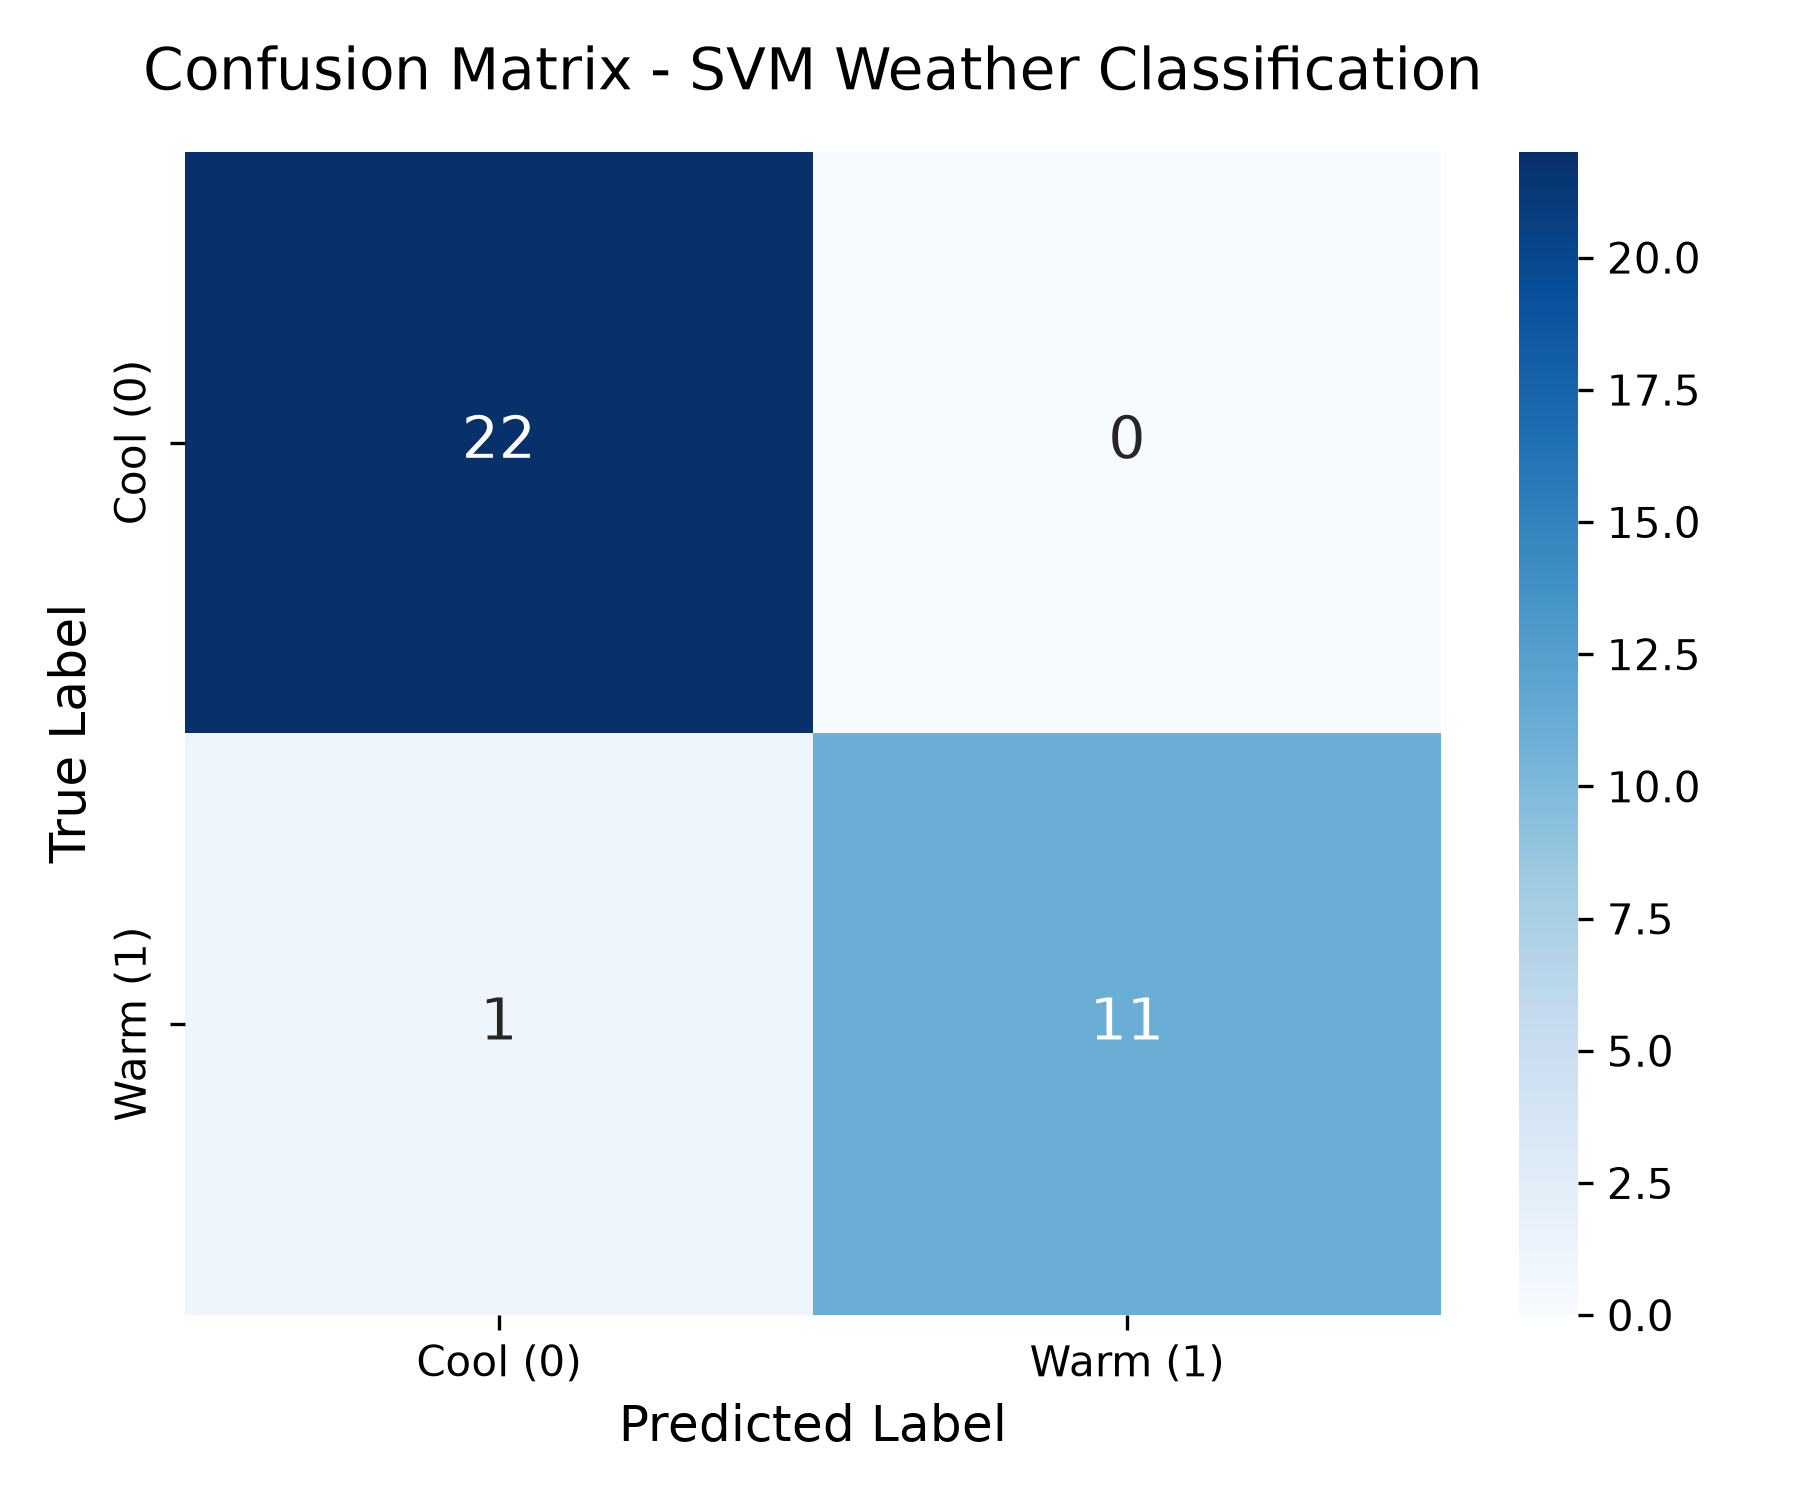

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("--- Model Performance Metrics ---")
print(f"Accuracy Score  : {accuracy:.4f} (or {accuracy * 100:.2f}%)")
print(f"Precision Score : {precision:.4f} (or {precision * 100:.2f}%)")
print(f"Recall Score    : {recall:.4f} (or {recall * 100:.2f}%)")
print(f"F1-Score        : {f1:.4f} (or {f1 * 100:.2f}%)")

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix using Seaborn heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Cool (0)', 'Warm (1)'], 
            yticklabels=['Cool (0)', 'Warm (1)'],
            annot_kws={"size": 14})
plt.title('Confusion Matrix - SVM Weather Classification', fontsize=14, pad=15)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

### **Observations:**
1. **High Overall Classification Accuracy**: The model achieved an outstanding classification accuracy of **97.06%** on the test set, indicating that the combined meteorological features (`temperature_2m`, `relative_humidity_2m`, `surface_pressure`, and `wind_speed_10m`) contain a very strong predictive signal for classifying weather conditions.
2. **Perfect Precision Score (100%)**: The model obtained a precision of **100.00%** with zero false positives ($FP=0$), which means every single instance predicted as 'Warm' was indeed a 'Warm' hour. The decision boundary successfully isolates the 'Warm' class without misclassifying any 'Cool' hours as 'Warm'.
3. **High Recall with Minor Boundary Misclassification**: The model achieved a recall of **91.67%** due to a single false negative ($FN=1$), where one 'Warm' hour was misclassified as 'Cool'. This indicates the model is highly sensitive in capturing warm conditions, with minor boundary ambiguity that slightly favors 'Cool' classifications near the $25^{\circ}\text{C}$ threshold.

## Task 5: Conclusion

**Findings & Experiment Conclusion:**
This experiment demonstrates that a Support Vector Machine (SVM) classifier with an RBF kernel can effectively classify weather conditions into "Warm" and "Cool" using Open-Meteo API hourly forecast features. By training on a standardized dataset from Bangalore, India, the model achieved a high Accuracy (97.06%) and a perfect Precision (100%).

**Importance of Feature Scaling:**
Feature scaling using `StandardScaler` is absolutely mandatory for distance-based algorithms like SVMs. Because SVM optimization constructs a hyperplane that maximizes the margin between classes using Euclidean distance, features with larger numerical ranges (like `surface_pressure` $\approx 900\text{ hPa}$) would dominate features with smaller ranges (like `wind_speed_10m` $\approx 5\text{ km/h}$), leading to a biased model. Standardizing features ensures all dimensions contribute equally.

**Advantages and Limitations of SVM:**
* **Advantage:** By using the Radial Basis Function (RBF) kernel, SVM can implicitly map data into higher-dimensional feature spaces, allowing it to efficiently handle complex, non-linear boundaries.
* **Limitation:** SVM has poor scalability, with training time complexity scaling between $O(N^2)$ and $O(N^3)$, making it computationally prohibitive for large datasets. It is also highly sensitive to hyperparameter selection (e.g., $C$ and $\gamma$).